In [14]:
import os
import random
import numpy as np
import pandas as pd
import torch
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

from models import NeuronLSTM

# ── Paths — edit these to match your run ──────────────────────────────────────
output_dir   = "./outputs/lstm_signal"
models_dir   = os.path.join(output_dir, "models")
preds_dir    = os.path.join(output_dir, "predictions")
base         = "./outputs/glm_input_data/"
split_path   = "test_indices_by_session.npy"

# r² file used as the selection criterion (passed as --r2_path to train_lstm_signal.py)
r2_ref_path  = "./outputs/lstm/r2_matrix.npy"

# match the values used during training
hidden_size  = 64
num_layers   = 1
window       = 10
num_neurons  = 77

action_enc_cols = [
    'frame_raw_500msMedian',
    'frame_YawPitch_abs_vel_sum_500msMedian',
    'upcoming_choice',
    'reward_window',
    'frame_raw_abs_acc_500msMedian',
    'frame_YawPitch_abs_acc_sum_500msMedian',
    'forward_vs_rotation_corr',
    'head_angle',
    'head_angle_vel',
    'movement_energy_smooth5',
    'lick_detected',
]
input_size = len(action_enc_cols)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [15]:
# ── Load behaviour + spike data ───────────────────────────────────────────────
beh_vals = np.load(os.path.join(base, 'behavior_glm_input.npy'), allow_pickle=True)
beh_idx  = np.load(os.path.join(base, 'behavior_glm_input_index.npy'), allow_pickle=True)
beh_cols = np.load(os.path.join(base, 'behavior_glm_input_columns.npy'), allow_pickle=True)

spk_vals = np.load(os.path.join(base, 'fr_full.npy'))
spk_idx  = np.load(os.path.join(base, 'fr_full_index.npy'), allow_pickle=True)
spk_cols = np.load(os.path.join(base, 'fr_full_columns.npy'), allow_pickle=True)

behavior_glm_loaded = pd.DataFrame(beh_vals, index=pd.Index(beh_idx), columns=beh_cols)
spikes_loaded       = pd.DataFrame(spk_vals, index=pd.Index(spk_idx),  columns=spk_cols)

spikes_loaded.index = pd.MultiIndex.from_tuples(
    spikes_loaded.index.map(lambda t: (t[0], t[1] // 40000 - 1))
)
spikes_unique_trials = set(idx[0] for idx in spikes_loaded.index)
behavior_glm_loaded  = behavior_glm_loaded[
    behavior_glm_loaded.index.map(lambda t: t[0] in spikes_unique_trials)
]
non_nan_rows        = behavior_glm_loaded.index[~behavior_glm_loaded.isna().any(axis=1)]
behavior_glm_loaded = behavior_glm_loaded.loc[non_nan_rows]
spikes_loaded       = spikes_loaded.loc[non_nan_rows]
behavior_glm_loaded = behavior_glm_loaded.drop('track_zone', axis=1)

session_ids  = behavior_glm_loaded.index.map(lambda x: x[0]).unique()
num_sessions = len(session_ids)
print(f'{num_sessions} sessions')

29 sessions


In [16]:
# ── Build session dataset ─────────────────────────────────────────────────────
session_dataset_singles = {}

for session_id in session_ids:
    session_mask   = behavior_glm_loaded.index.map(lambda x: x[0]) == session_id
    beh            = behavior_glm_loaded[session_mask].copy()
    spikes_session = spikes_loaded[session_mask].copy()

    for col in action_enc_cols:
        if col in beh.columns:
            beh[col]  = beh[col].astype(float)
            mean_val  = beh[col].mean()
            std_val   = beh[col].std() + 1e-8
            beh[col]  = (beh[col] - mean_val) / std_val

    spikes_session = spikes_session.astype(float)
    label_stds     = []
    for col in spikes_session.columns:
        mean_val = spikes_session[col].mean()
        std_val  = spikes_session[col].std() + 1e-8
        label_stds.append(std_val)
        spikes_session[col] = (spikes_session[col] - mean_val) / std_val

    data_by_trial, labels_by_trial = {}, {}
    for trial_id in beh['trial_id'].unique():
        trial_mask                = beh['trial_id'] == trial_id
        data_by_trial[trial_id]   = beh.loc[trial_mask, action_enc_cols].values.astype(np.float32)
        labels_by_trial[trial_id] = spikes_session.loc[trial_mask].values.astype(np.float32)

    session_dataset_singles[session_id] = {
        'data':       data_by_trial,
        'labels':     labels_by_trial,
        'label_stds': label_stds,
    }

test_indices_by_session = np.load(split_path, allow_pickle=True).item()
print('Dataset built.')

Dataset built.


In [17]:
# ── Load result matrices ──────────────────────────────────────────────────────
r2_matrix         = np.load(os.path.join(output_dir, 'r2_matrix.npy'))
mse_matrix        = np.load(os.path.join(output_dir, 'mse_matrix.npy'))
pearson_r2_matrix = np.load(os.path.join(output_dir, 'pearson_r2_matrix.npy'))
silence_mask      = np.load(os.path.join(output_dir, 'mask.npy'))
active_by_session = np.load(os.path.join(output_dir, 'active_neurons_by_session.npy'),
                             allow_pickle=True).item()

# reference r² used for neuron selection
r2_ref = np.load(r2_ref_path)
assert r2_ref.shape == r2_matrix.shape, \
    f"Shape mismatch: ref {r2_ref.shape} vs new {r2_matrix.shape}"

# selected_mask: True where a neuron was active (selected by r2 threshold) for this session
selected_mask = ~np.isnan(r2_matrix)

r2_matrix_clipped = np.clip(r2_matrix, 0.0, 1.0)
r2_ref_clipped    = np.clip(r2_ref,    0.0, 1.0)

print(f'Matrix shape             : {r2_matrix.shape}  (sessions x neurons)')
print(f'Selected neuron-sessions : {selected_mask.sum()}')
print(f'Silent (never included)  : {silence_mask.sum()}')
print(f'Not selected by r² thresh: {(~selected_mask & ~silence_mask).sum()}')

Matrix shape             : (29, 77)  (sessions x neurons)
Selected neuron-sessions : 85
Silent (never included)  : 168
Not selected by r² thresh: 1980


/tmp/ipykernel_881925/110664380.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('RdYlGn', 3)


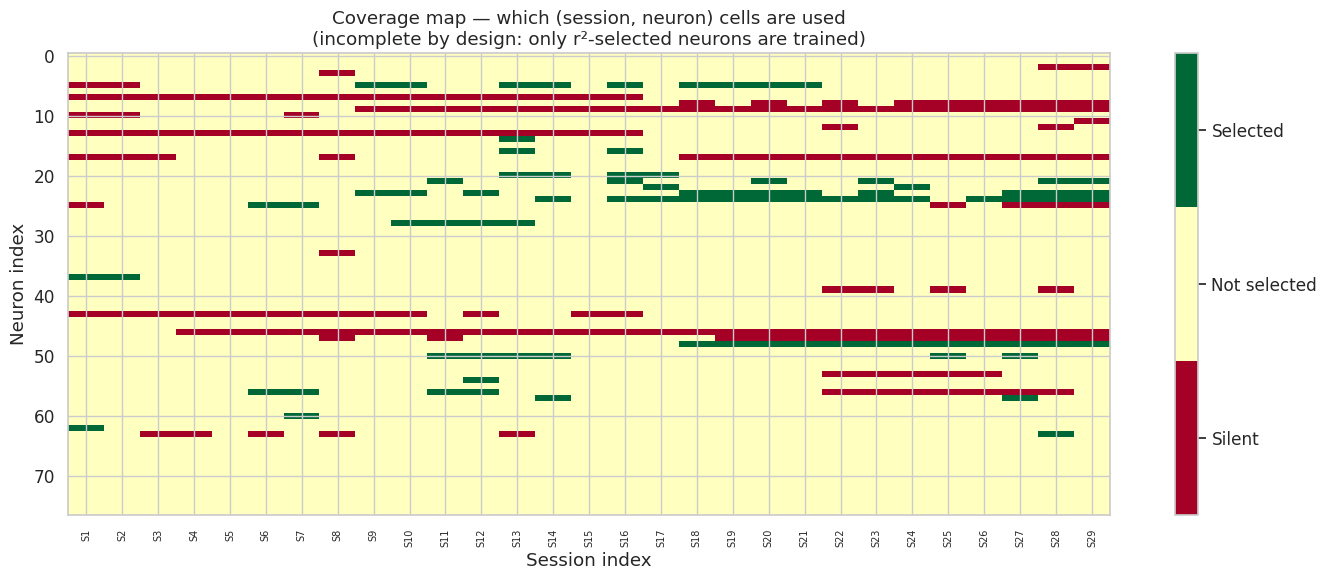

Selected neurons per session: [2, 1, 0, 0, 0, 2, 3, 0, 2, 3, 4, 5, 6, 5, 0, 5, 3, 4, 4, 5, 4, 2, 4, 3, 2, 2, 5, 5, 4]


In [18]:
# ── Coverage map: which (session, neuron) cells are populated ─────────────────
# Three categories: selected+has_score | silent | not selected
coverage = np.zeros((num_sessions, num_neurons), dtype=int)
coverage[selected_mask]                      = 2  # selected
coverage[silence_mask & ~selected_mask]      = 0  # silent
coverage[~selected_mask & ~silence_mask]     = 1  # not selected by threshold

fig, ax = plt.subplots(figsize=(14, 6))
cmap    = plt.cm.get_cmap('RdYlGn', 3)
im      = ax.imshow(coverage.T, aspect='auto', cmap=cmap, vmin=-0.5, vmax=2.5)
cbar    = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Silent', 'Not selected', 'Selected'])
ax.set_xlabel('Session index')
ax.set_ylabel('Neuron index')
ax.set_title('Coverage map — which (session, neuron) cells are used\n'
             '(incomplete by design: only r²-selected neurons are trained)')
ax.set_xticks(range(num_sessions))
ax.set_xticklabels([f'S{i+1}' for i in range(num_sessions)], rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

counts = [coverage[i].tolist().count(2) for i in range(num_sessions)]
print('Selected neurons per session:', counts)

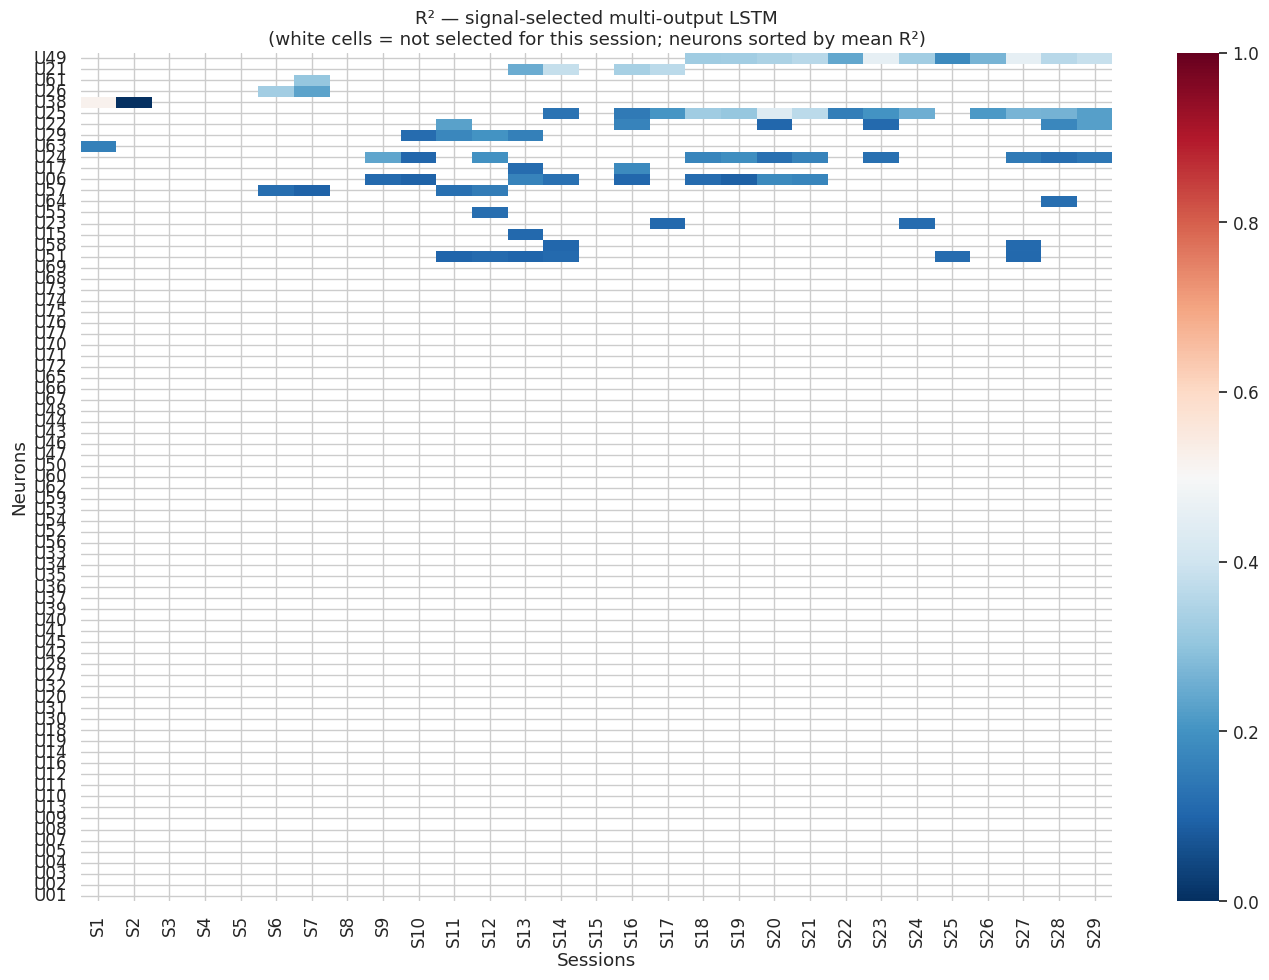

In [19]:
# ── R² heatmap (NaN cells shown as white) ─────────────────────────────────────
masked_r2    = ma.array(r2_matrix_clipped, mask=~selected_mask)
neuron_mean  = masked_r2.mean(axis=0).filled(np.nan)
neuron_order = np.argsort(np.nan_to_num(neuron_mean))[::-1]

r2_sorted    = r2_matrix_clipped[:, neuron_order].T
mask_sorted  = (~selected_mask)[:, neuron_order].T

plt.figure(figsize=(14, 10))
sns.heatmap(r2_sorted, mask=mask_sorted, cmap='RdBu_r', cbar=True,
            vmin=0, vmax=1,
            xticklabels=[f'S{i+1}' for i in range(num_sessions)],
            yticklabels=[f'U{neuron_order[i]+1:02d}' for i in range(num_neurons)])
plt.title('R² — signal-selected multi-output LSTM\n'
          '(white cells = not selected for this session; neurons sorted by mean R²)')
plt.xlabel('Sessions')
plt.ylabel('Neurons')
plt.tight_layout()
plt.show()

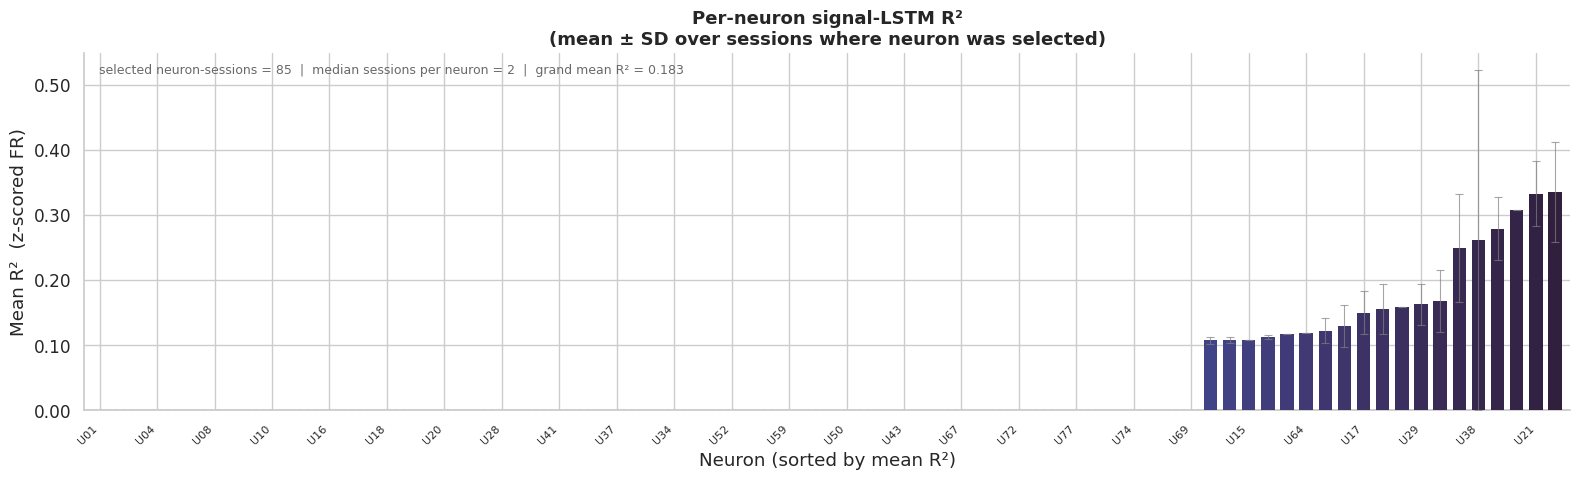

In [20]:
# ── Per-neuron R² bar chart (only sessions where neuron was selected) ──────────
masked_r2   = ma.array(r2_matrix_clipped, mask=~selected_mask)
neuron_mean = masked_r2.mean(axis=0).filled(np.nan)
neuron_std  = masked_r2.std(axis=0).filled(np.nan)
neuron_n    = selected_mask.sum(axis=0)  # how many sessions each neuron was trained on

order   = np.argsort(np.nan_to_num(neuron_mean))
x       = np.arange(num_neurons)
labels  = [f'U{i+1:02d}' for i in order]
means_s = neuron_mean[order]
stds_s  = neuron_std[order]
ns_s    = neuron_n[order]

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
palette = sns.color_palette('mako_r', as_cmap=True)
colors  = palette(np.linspace(0.15, 0.85, num_neurons))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, means_s, width=0.7, color=colors, zorder=3, linewidth=0)
ax.errorbar(x, means_s, yerr=stds_s,
            fmt='none', ecolor='gray', elinewidth=0.8,
            capsize=3, capthick=0.8, zorder=4, alpha=0.7)
ax.axhline(0, color='firebrick', linestyle='--', linewidth=1)

ax.set_xticks(x[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Neuron (sorted by mean R²)')
ax.set_ylabel('Mean R²  (z-scored FR)')
ax.set_title('Per-neuron signal-LSTM R²\n'
             '(mean ± SD over sessions where neuron was selected)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.set_xlim(-0.8, num_neurons - 0.2)
ax.spines[['top', 'right']].set_visible(False)

grand_mean = np.nanmean(neuron_mean)
median_n   = int(np.median(neuron_n[neuron_n > 0])) if (neuron_n > 0).any() else 0
ax.annotate(
    f'selected neuron-sessions = {selected_mask.sum()}  |  '
    f'median sessions per neuron = {median_n}  |  '
    f'grand mean R² = {grand_mean:.3f}',
    xy=(0.01, 0.97), xycoords='axes fraction',
    va='top', ha='left', fontsize=9, color='dimgray'
)
plt.tight_layout()
plt.show()

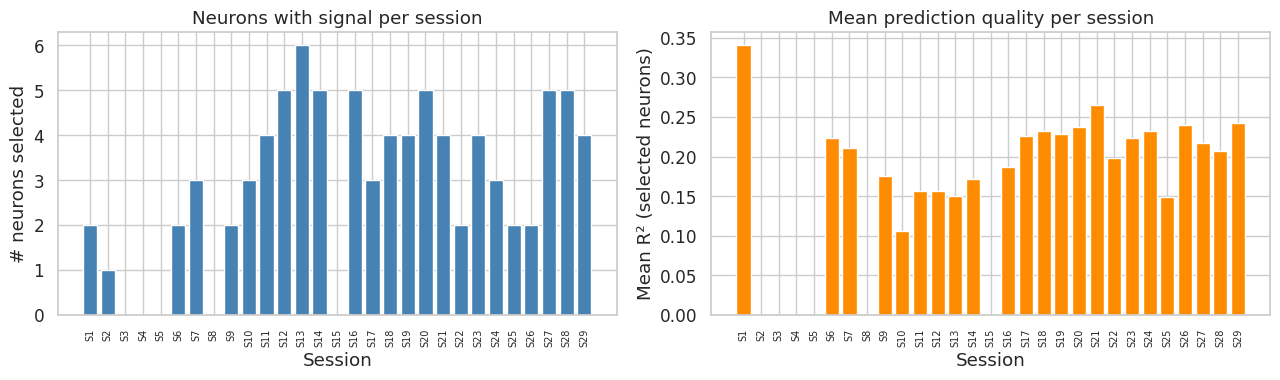

Sessions with ≥1 selected neuron: 24/29


In [21]:
# ── Per-session summary: how many neurons selected vs. how well they're fit ───
sess_n_selected  = selected_mask.sum(axis=1)
sess_mean_r2     = np.array([np.nanmean(r2_matrix_clipped[i, selected_mask[i]])
                              if selected_mask[i].any() else np.nan
                              for i in range(num_sessions)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(num_sessions), sess_n_selected, color='steelblue')
axes[0].set_xlabel('Session')
axes[0].set_ylabel('# neurons selected')
axes[0].set_title('Neurons with signal per session')
axes[0].set_xticks(range(num_sessions))
axes[0].set_xticklabels([f'S{i+1}' for i in range(num_sessions)], rotation=90, fontsize=7)

axes[1].bar(range(num_sessions), sess_mean_r2, color='darkorange')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Session')
axes[1].set_ylabel('Mean R² (selected neurons)')
axes[1].set_title('Mean prediction quality per session')
axes[1].set_xticks(range(num_sessions))
axes[1].set_xticklabels([f'S{i+1}' for i in range(num_sessions)], rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

print(f'Sessions with ≥1 selected neuron: {(sess_n_selected > 0).sum()}/{num_sessions}')

/tmp/ipykernel_881925/2559472087.py:40: RuntimeWarning: Mean of empty slice
  neuron_delta_mean = np.nanmean(delta_mat, axis=0)


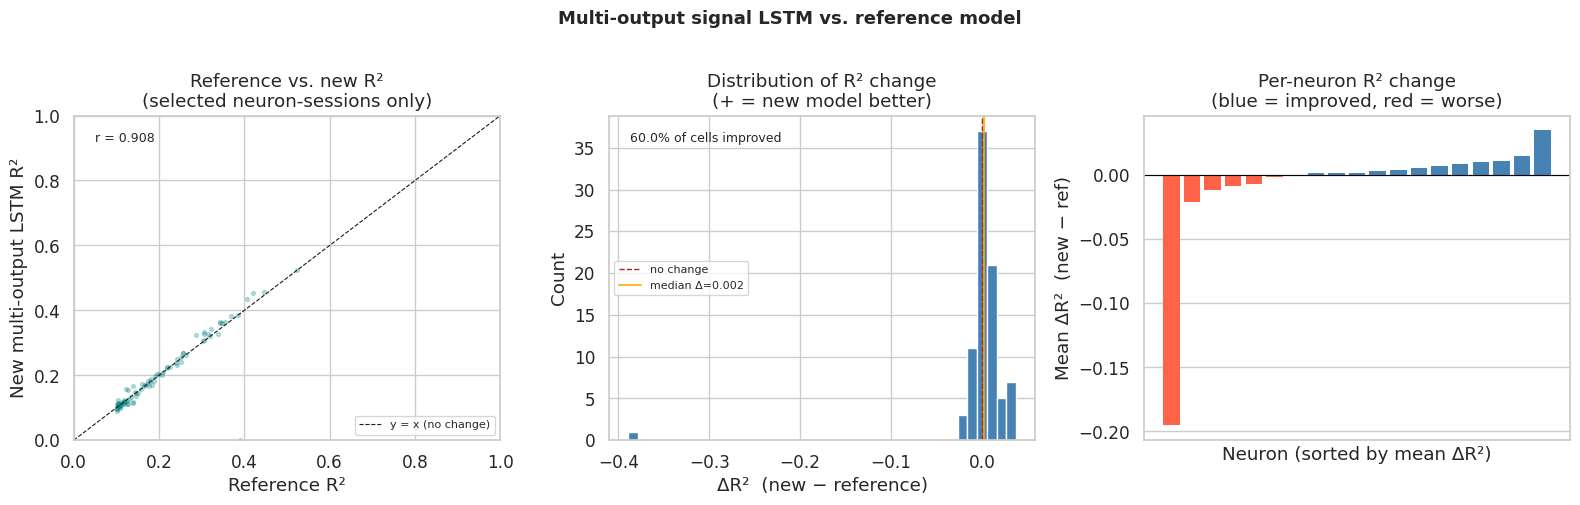

Reference  — mean R²: 0.2024  median: 0.1716
New model  — mean R²: 0.2017  median: 0.1690
ΔR²        — mean  : -0.0006  median: 0.0021
Cells improved      : 51/85  (60.0%)


In [22]:
# ── Compare new multi-output LSTM r² vs reference r² ─────────────────────────
# Only compare cells that were selected (i.e. had reference r² >= threshold)

ref_vals = r2_ref_clipped[selected_mask]
new_vals = r2_matrix_clipped[selected_mask]
delta    = new_vals - ref_vals   # positive = new model is better

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (1) Scatter: ref vs new ───────────────────────────────────────────────────
ax = axes[0]
ax.scatter(ref_vals, new_vals, alpha=0.25, s=8, color='teal', rasterized=True)
lim = (0, 1)
ax.plot(lim, lim, 'k--', linewidth=0.8, label='y = x (no change)')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Reference R²')
ax.set_ylabel('New multi-output LSTM R²')
ax.set_title('Reference vs. new R²\n(selected neuron-sessions only)')
ax.legend(fontsize=8)
corr = np.corrcoef(ref_vals, new_vals)[0, 1]
ax.annotate(f'r = {corr:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9)

# ── (2) Distribution of Δr² (new − ref) ──────────────────────────────────────
ax = axes[1]
ax.hist(delta, bins=40, color='steelblue', edgecolor='white')
ax.axvline(0,          color='firebrick', linestyle='--', linewidth=1, label='no change')
ax.axvline(np.median(delta), color='orange', linestyle='-', linewidth=1.2,
           label=f'median Δ={np.median(delta):.3f}')
ax.set_xlabel('ΔR²  (new − reference)')
ax.set_ylabel('Count')
ax.set_title('Distribution of R² change\n(+ = new model better)')
ax.legend(fontsize=8)
frac_better = np.mean(delta > 0)
ax.annotate(f'{frac_better*100:.1f}% of cells improved',
            xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9)

# ── (3) Per-neuron mean Δr² (sorted) ─────────────────────────────────────────
ax = axes[2]
delta_mat = np.where(selected_mask, r2_matrix_clipped - r2_ref_clipped, np.nan)
neuron_delta_mean = np.nanmean(delta_mat, axis=0)
order = np.argsort(neuron_delta_mean)
colors = ['tomato' if v < 0 else 'steelblue' for v in neuron_delta_mean[order]]
ax.bar(range(num_neurons), neuron_delta_mean[order], color=colors, linewidth=0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Neuron (sorted by mean ΔR²)')
ax.set_ylabel('Mean ΔR²  (new − ref)')
ax.set_title('Per-neuron R² change\n(blue = improved, red = worse)')
ax.set_xticks([])

plt.suptitle('Multi-output signal LSTM vs. reference model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Reference  — mean R²: {np.mean(ref_vals):.4f}  median: {np.median(ref_vals):.4f}')
print(f'New model  — mean R²: {np.mean(new_vals):.4f}  median: {np.median(new_vals):.4f}')
print(f'ΔR²        — mean  : {np.mean(delta):.4f}  median: {np.median(delta):.4f}')
print(f'Cells improved      : {np.sum(delta > 0)}/{len(delta)}  ({frac_better*100:.1f}%)')

In [37]:
neuron_delta_mean

array([        nan,         nan,         nan,         nan,         nan,
       -0.00862614,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,  0.00417918,
               nan,  0.00526607,         nan,         nan,         nan,
        0.01497759,  0.00672279, -0.00054497,  0.00144697,  0.00985518,
       -0.01132625,         nan,         nan,  0.00870137,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan, -0.19532147,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,  0.01101072,         nan,
       -0.00152517,         nan,         nan,         nan,  0.00178492,
               nan,  0.00173913, -0.00712177,         nan,         nan,
        0.00300139,         nan,  0.03492862, -0.02066207,         nan,
               nan,         nan,         nan,         nan,      

Sessions with ≥3 neurons R²>0.1: 15


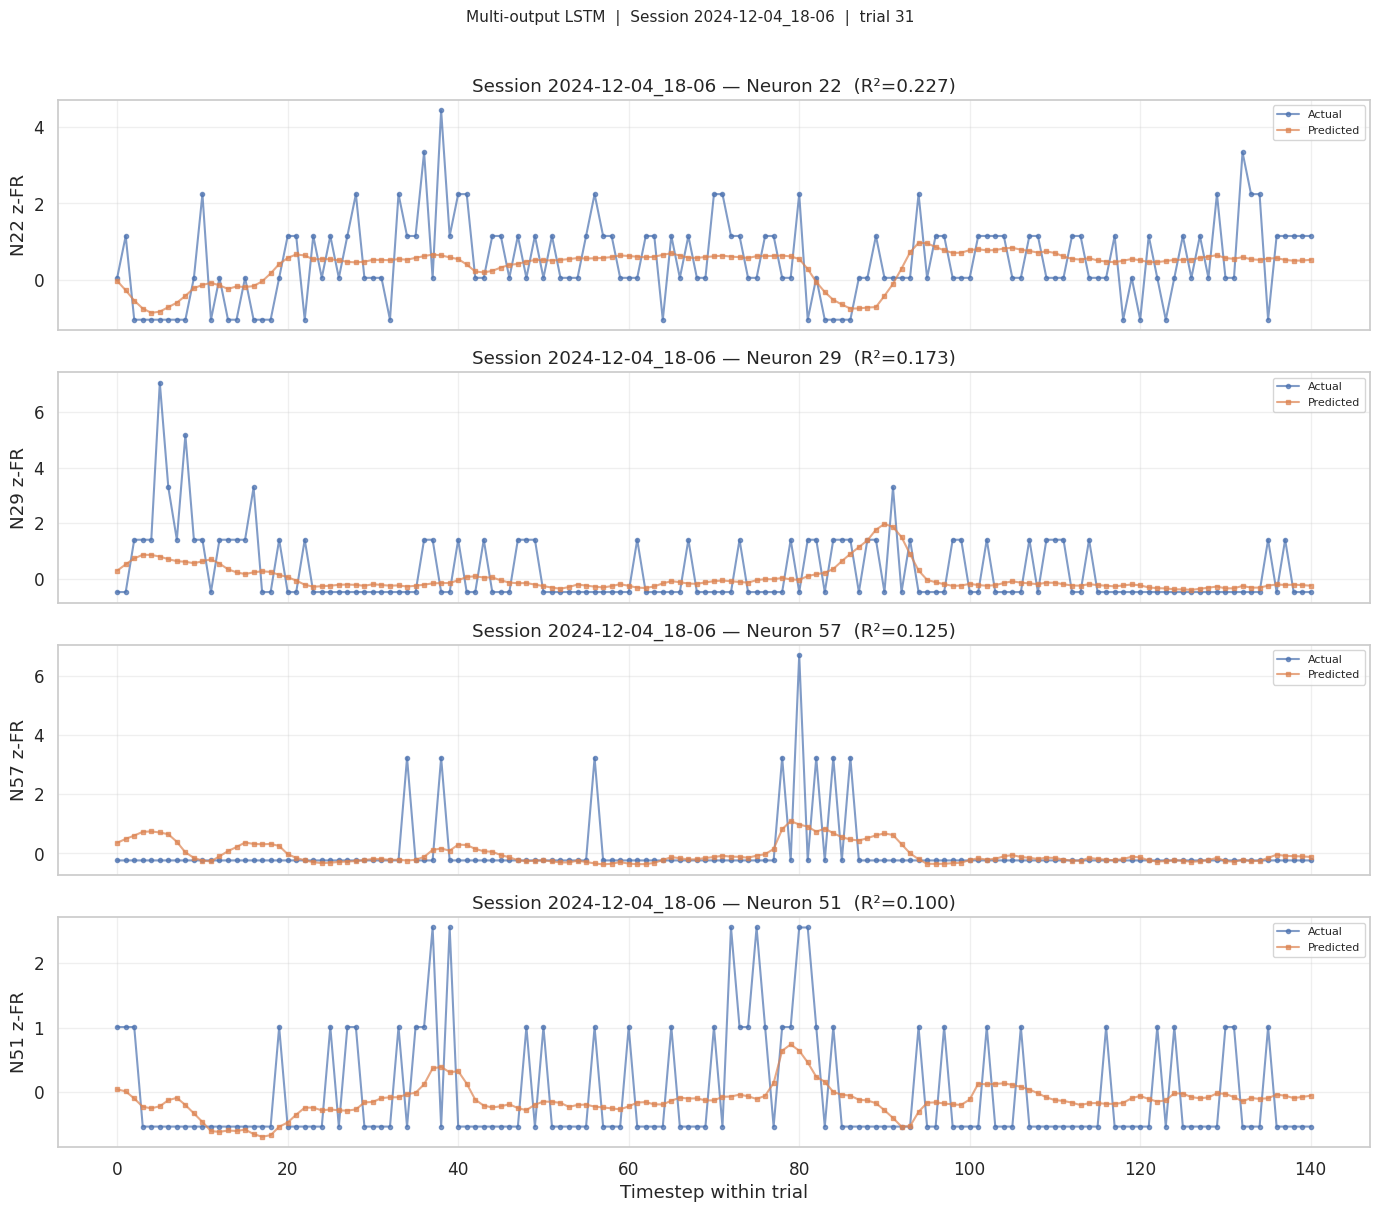

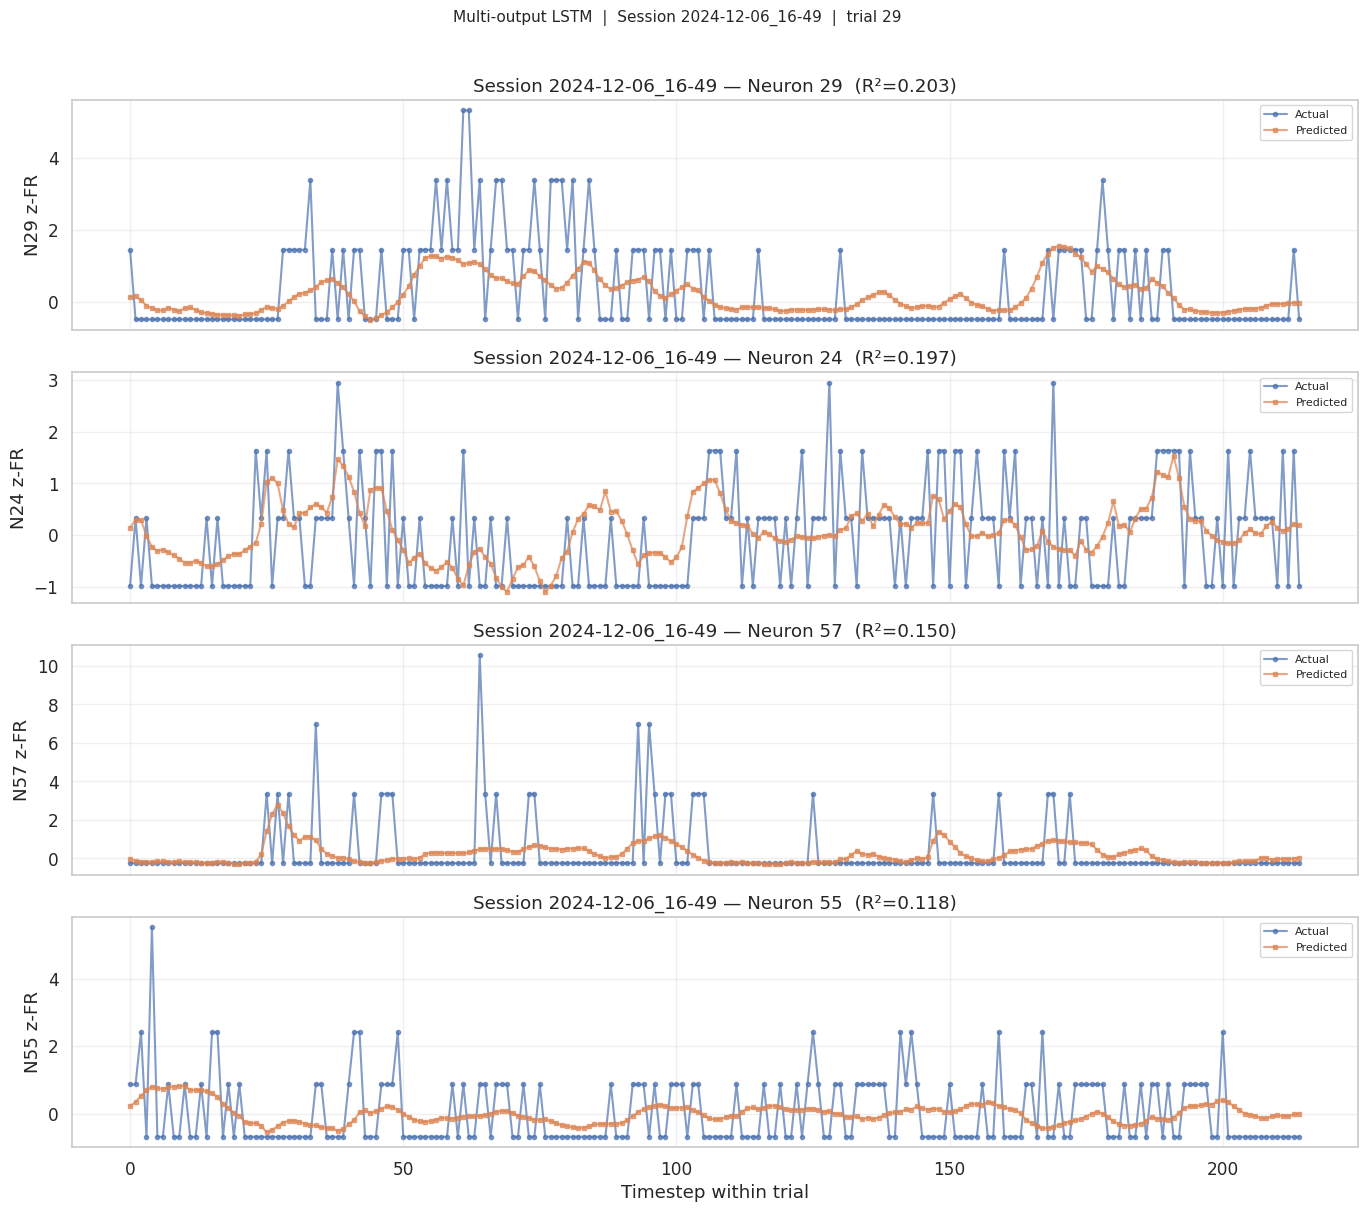

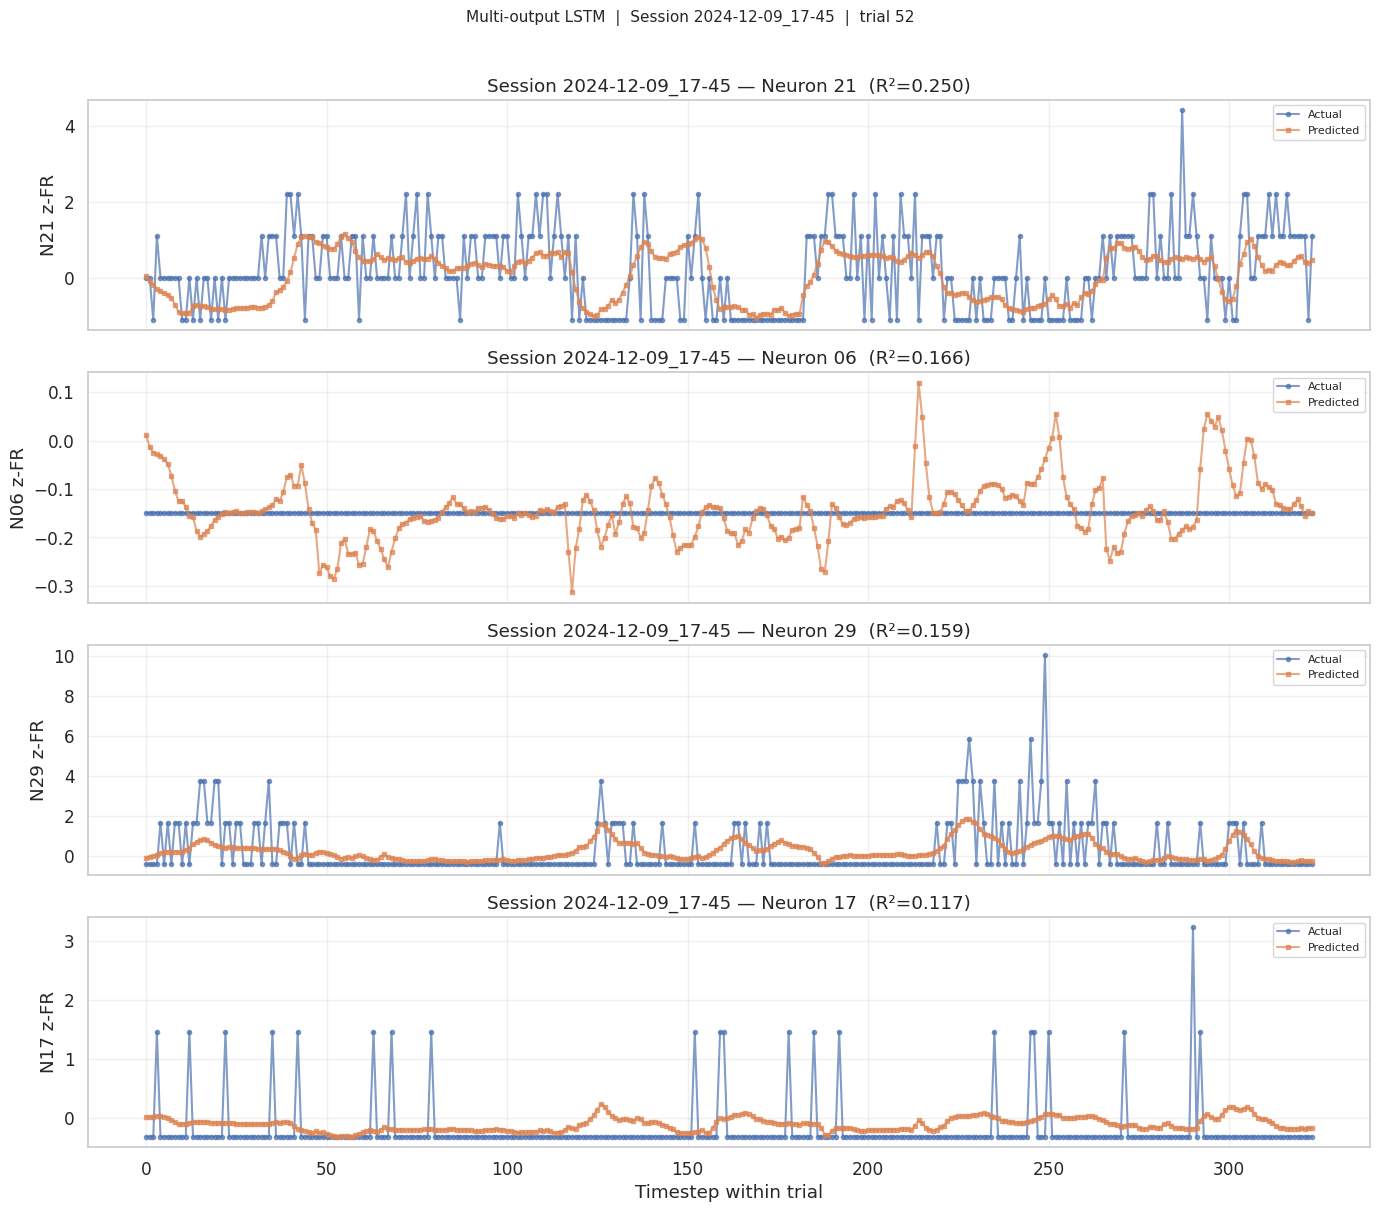

In [40]:
# ── Trial-level prediction traces for a random session with good coverage ─────
def make_windows_eval(data_dict, labels_dict, trial_ids, window, neuron_indices):
    X_list, y_list = [], []
    for tid in trial_ids:
        if tid not in data_dict:
            continue
        data   = data_dict[tid]
        labels = labels_dict[tid][:, neuron_indices]
        T      = len(data)
        padded = np.zeros((window - 1 + T, data.shape[1]), dtype=np.float32)
        padded[window - 1:] = data
        for t in range(T):
            X_list.append(padded[t: t + window])
            y_list.append(labels[t])
    if not X_list:
        return None, None
    return np.stack(X_list), np.stack(y_list)


# pick sessions with at least 3 selected neurons that have R² > 0.1
good_sessions = [
    (i, sid) for i, sid in enumerate(session_ids)
    if np.nansum(r2_matrix_clipped[i] > 0.1) >= 3
]
print(f'Sessions with ≥3 neurons R²>0.1: {len(good_sessions)}')

MAX_PLOT_SESSIONS = 3
MAX_NEURONS_PER   = 4

for sess_idx, session_id in good_sessions[:MAX_PLOT_SESSIONS]:
    active         = np.array(active_by_session[session_id])
    model_path     = os.path.join(models_dir, f'session_{sess_idx:02d}.pt')
    if not os.path.exists(model_path) or len(active) == 0:
        continue

    # rank active neurons by R²
    active_r2   = r2_matrix_clipped[sess_idx, active]
    best_order  = np.argsort(active_r2)[::-1][:MAX_NEURONS_PER]
    plot_ki     = best_order                        # indices INTO active array
    plot_nidx   = active[plot_ki]                   # global neuron indices

    adjusted_hidden_size = round(hidden_size * (len(active) ** 0.5))

    model = NeuronLSTM(input_size, adjusted_hidden_size, num_layers,
                       output_size=len(active), dropout=0.0).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    sd           = session_dataset_singles[session_id]
    test_trials  = [int(i) for i in test_indices_by_session[session_id]]
    trial_id     = random.choice(test_trials)

    trial_data   = sd['data'][trial_id]
    trial_labels = sd['labels'][trial_id]   # (T, num_neurons)
    T            = len(trial_data)
    padded       = np.zeros((window - 1 + T, trial_data.shape[1]), dtype=np.float32)
    padded[window - 1:] = trial_data
    X_np = np.stack([padded[t: t + window] for t in range(T)])

    with torch.no_grad():
        preds = model(torch.tensor(X_np, dtype=torch.float32).to(device))
        if preds.dim() == 1:
            preds = preds.unsqueeze(1)
        preds_np = preds.cpu().numpy()  # (T, k)

    n_plot = len(plot_ki)
    fig, axes = plt.subplots(n_plot, 1, figsize=(14, 3 * n_plot), sharex=True)
    if n_plot == 1:
        axes = [axes]
    time_steps = np.arange(T)

    for pi, (ki, nidx) in enumerate(zip(plot_ki, plot_nidx)):
        actual = trial_labels[:, nidx]
        pred   = preds_np[:, ki]
        r2_val = r2_matrix_clipped[sess_idx, nidx]
        axes[pi].plot(time_steps, actual, 'o-', label='Actual',    alpha=0.7, markersize=3)
        axes[pi].plot(time_steps, pred,   's-', label='Predicted', alpha=0.7, markersize=3)
        axes[pi].set_ylabel(f'N{nidx+1:02d} z-FR')
        axes[pi].set_title(f'Session {session_id} — Neuron {nidx+1:02d}  (R²={r2_val:.3f})')
        axes[pi].legend(loc='upper right', fontsize=8)
        axes[pi].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Timestep within trial')
    plt.suptitle(f'Multi-output LSTM  |  Session {session_id}  |  trial {trial_id}',
                 y=1.01, fontsize=11)
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()

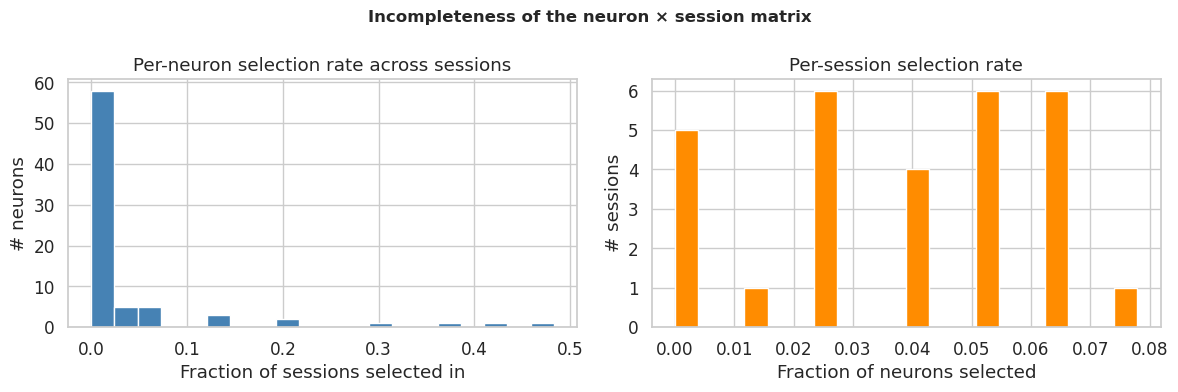

Overall fill rate: 3.8%
Neurons present in ≥50% of sessions: 0
Neurons never selected              : 58


In [41]:
# ── Incompleteness summary ─────────────────────────────────────────────────────
# Show the fill-rate of the matrix as a histogram over neurons
fill_rate_per_neuron   = selected_mask.mean(axis=0)   # fraction of sessions where neuron selected
fill_rate_per_session  = selected_mask.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fill_rate_per_neuron, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Fraction of sessions selected in')
axes[0].set_ylabel('# neurons')
axes[0].set_title('Per-neuron selection rate across sessions')

axes[1].hist(fill_rate_per_session, bins=20, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Fraction of neurons selected')
axes[1].set_ylabel('# sessions')
axes[1].set_title('Per-session selection rate')

plt.suptitle('Incompleteness of the neuron × session matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Overall fill rate: {selected_mask.mean()*100:.1f}%')
print(f'Neurons present in ≥50% of sessions: {(fill_rate_per_neuron >= 0.5).sum()}')
print(f'Neurons never selected              : {(fill_rate_per_neuron == 0).sum()}')

In [43]:

# ── Extract action embeddings (LSTM output at final timestep, pre-FC) ─────────
# For each session, run test windows through model.embed() to get the embedding
# trajectory.  Shape per session: (N_test_windows, hidden_size).

embeddings_by_session = {}   # session_id -> (N, hidden_size) np.float32

for sess_idx, session_id in enumerate(session_ids):
    active     = np.array(active_by_session[session_id])
    model_path = os.path.join(models_dir, f'session_{sess_idx:02d}.pt')
    if not os.path.exists(model_path) or len(active) == 0:
        continue

    sd           = session_dataset_singles[session_id]
    test_trials  = [int(i) for i in test_indices_by_session[session_id]]

    X_test, _ = make_windows_eval(sd['data'], sd['labels'], test_trials, window, active)
    if X_test is None:
        continue
    
    adjusted_hidden_size = round(hidden_size * (len(active) ** 0.5))
    model = NeuronLSTM(input_size, adjusted_hidden_size, num_layers,
                       output_size=len(active), dropout=0.0).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    loader    = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32)),
        batch_size=2048)
    emb_list  = []
    with torch.no_grad():
        for (xb,) in loader:
            # embed() returns the LSTM output at the last timestep (pre-FC)
            emb_list.append(model.embed(xb.to(device)).cpu().numpy())

    embeddings_by_session[session_id] = np.concatenate(emb_list, axis=0)
    del model
    torch.cuda.empty_cache()

    print(f'  Session {sess_idx+1:02d} ({session_id}): '
          f'embedding shape {embeddings_by_session[session_id].shape}')

print('Done extracting embeddings.')


  Session 01 (2024-11-14_16-40): embedding shape (5075, 91)
  Session 02 (2024-11-15_15-48): embedding shape (8349, 64)
  Session 06 (2024-11-26_16-39): embedding shape (5659, 91)
  Session 07 (2024-11-28_17-41): embedding shape (6933, 111)
  Session 09 (2024-12-02_16-09): embedding shape (5367, 91)
  Session 10 (2024-12-03_16-23): embedding shape (6229, 111)
  Session 11 (2024-12-04_18-06): embedding shape (5404, 128)
  Session 12 (2024-12-06_16-49): embedding shape (5491, 143)
  Session 13 (2024-12-09_17-45): embedding shape (5689, 157)
  Session 14 (2024-12-10_17-20): embedding shape (6503, 143)
  Session 16 (2024-12-12_16-13): embedding shape (4977, 143)
  Session 17 (2024-12-13_17-10): embedding shape (5885, 111)
  Session 18 (2025-01-14_18-08): embedding shape (5585, 128)
  Session 19 (2025-01-15_17-18): embedding shape (6177, 128)
  Session 20 (2025-01-16_17-47): embedding shape (6468, 143)
  Session 21 (2025-01-17_16-55): embedding shape (6880, 128)
  Session 22 (2025-01-21_18-